In [45]:
!pip install vaderSentiment scikit-learn emoji openpyxl -q

In [46]:
import pandas as pd
import re
import emoji
import warnings
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [47]:
combined = pd.read_excel("/combined_lpg_data.xlsx")
print(combined.shape)
print(combined.head())

(810, 6)
   sno                                            comment    hashtags  \
0    1  q did people have to stand in queue for gas cy...        none   
1    2  india s lpg crisis is now rewriting menus in r...  #bengaluru   
2    3  gas cylinder booked on st march which delivere...        none   
3    4  indian woman needed helping hand during lpg cr...        none   
4    5  domestic supply of lpg is fine but commerciall...        none   

        time type  word_count  
0 2026-05-03    x          25  
1 2026-05-03    x          11  
2 2026-05-03    x          18  
3 2026-05-03    x          21  
4 2026-04-27    x          18  


In [48]:
analyzer = SentimentIntensityAnalyzer()

resolution_words = {
    'over'      :  3.5,
    'ended'     :  3.5,
    'resolved'  :  3.5,
    'finished'  :  3.0,
    'stopped'   :  3.0,
    'ceased'    :  3.0,
    'concluded' :  3.0,
    'war'       : -0.5,
    'crisis'    : -0.5,
    'conflict'  : -0.5,
    'shortage'  : -0.8,
    'tension'   : -0.5,
    'reduced'   :  2.0,
    'stable'    :  2.5,
    'relief'    :  2.5,
    'affordable':  2.5,
    'subsidy'   :  2.0,
    'improved'  :  2.0,
    'better'    :  1.5,
    'normal'    :  1.5,
    'fixed'     :  2.0,
    'cheap'     :  2.0,
    'cheaper'   :  2.0,
}
analyzer.lexicon.update(resolution_words)
print(f"Lexicon updated — {len(resolution_words)} words added!")

Lexicon updated — 23 words added!


In [55]:
def get_vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.15:    return 'Positive', round(score, 3)
    elif score <= -0.15: return 'Negative', round(score, 3)
    else:                return 'Neutral',  round(score, 3)

combined[['vader_label','vader_score']] = combined['comment'].apply(
    lambda x: pd.Series(get_vader_sentiment(x))
)
print("\nLabel distribution:")
print(combined['vader_label'].value_counts())
print(f"\n{combined['vader_label'].value_counts(normalize=True).round(3) * 100}")



Label distribution:
vader_label
Positive    315
Negative    273
Neutral     222
Name: count, dtype: int64

vader_label
Positive    38.9
Negative    33.7
Neutral     27.4
Name: proportion, dtype: float64


In [56]:
def handle_negation(text):
    return re.sub(
        r'\b(not|no|never|neither|nor|cannot|cant|wont|isnt|arent|wasnt)\s+(\w+)',
        lambda m: m.group(1) + '_' + m.group(2), str(text)
    )

combined['comment_neg'] = combined['comment'].apply(handle_negation)

X = combined['comment_neg']   # use negation-handled text
y = combined['vader_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,3),
                        min_df=2, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
y_pred = lr.predict(X_test_tfidf)

print("── Baseline Model Report (LR + negation) ──")
print(classification_report(y_test, y_pred))

── Baseline Model Report (LR + negation) ──
              precision    recall  f1-score   support

    Negative       0.59      0.53      0.56        55
     Neutral       0.54      0.68      0.60        44
    Positive       0.75      0.68      0.72        63

    accuracy                           0.63       162
   macro avg       0.63      0.63      0.62       162
weighted avg       0.64      0.63      0.63       162



In [57]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced'),
    'SVM (Linear)'        : SVC(kernel='linear', class_weight='balanced', probability=True),
    'SVM (RBF)'           : SVC(kernel='rbf',    class_weight='balanced', probability=True),
    'Naive Bayes'         : MultinomialNB(),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = []
for name, model in models.items():
    try:
        model.fit(X_train_tfidf, y_train)
        y_pred_m = model.predict(X_test_tfidf)
        acc      = accuracy_score(y_test, y_pred_m)
        report   = classification_report(y_test, y_pred_m, output_dict=True)
        results.append({
            'Model'      : name,
            'Accuracy'   : round(acc, 3),
            'F1 Negative': round(report['Negative']['f1-score'], 3),
            'F1 Neutral' : round(report['Neutral']['f1-score'],  3),
            'F1 Positive': round(report['Positive']['f1-score'], 3),
            'Weighted F1': round(report['weighted avg']['f1-score'], 3),
            'Macro F1'   : round(report['macro avg']['f1-score'],    3),
        })
        print(f"\n── {name} ──")
        print(classification_report(y_test, y_pred_m))
    except Exception as e:
        print(f"{name} failed: {e}")

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df.index += 1
print("\n" + "=" * 65)
print("MODEL COMPARISON SUMMARY")
print("=" * 65)
print(results_df.to_string())


── Logistic Regression ──
              precision    recall  f1-score   support

    Negative       0.59      0.53      0.56        55
     Neutral       0.54      0.68      0.60        44
    Positive       0.75      0.68      0.72        63

    accuracy                           0.63       162
   macro avg       0.63      0.63      0.62       162
weighted avg       0.64      0.63      0.63       162


── SVM (Linear) ──
              precision    recall  f1-score   support

    Negative       0.57      0.51      0.54        55
     Neutral       0.54      0.66      0.59        44
    Positive       0.69      0.65      0.67        63

    accuracy                           0.60       162
   macro avg       0.60      0.61      0.60       162
weighted avg       0.61      0.60      0.60       162


── SVM (RBF) ──
              precision    recall  f1-score   support

    Negative       0.60      0.45      0.52        55
     Neutral       0.54      0.61      0.57        44
    Positiv

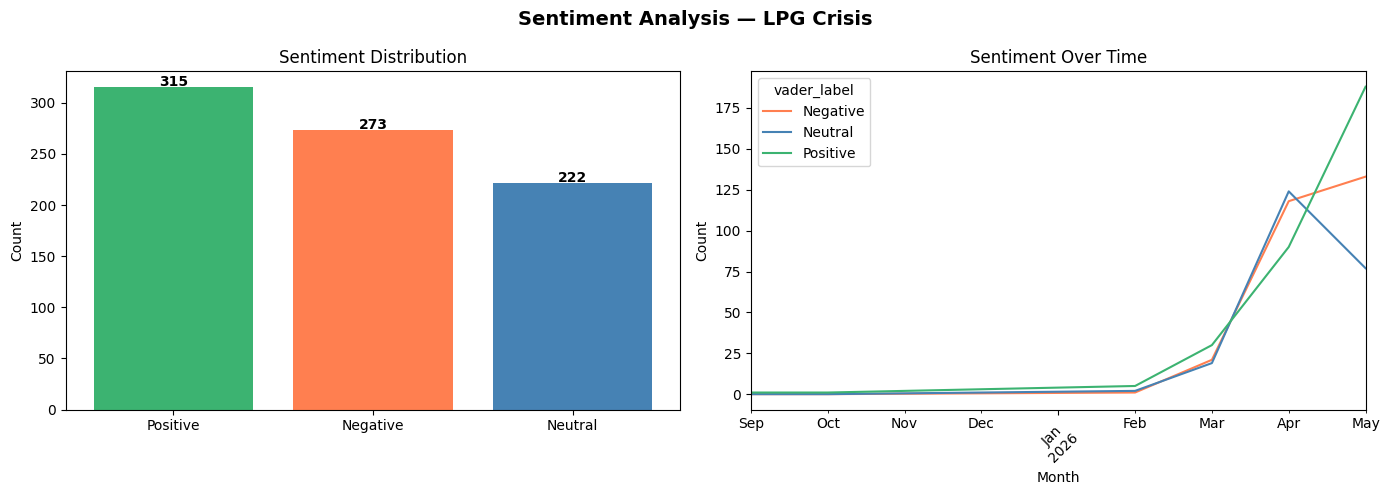

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Analysis — LPG Crisis', fontsize=14, fontweight='bold')

colors = {'Positive':'mediumseagreen','Negative':'coral','Neutral':'steelblue'}

vader_counts = combined['vader_label'].value_counts()
axes[0].bar(vader_counts.index, vader_counts.values,
            color=[colors.get(l,'grey') for l in vader_counts.index])
axes[0].set_title('Sentiment Distribution')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(vader_counts.items()):
    axes[0].text(i, val + 1, str(val), ha='center', fontweight='bold')

sentiment_time = combined.groupby(
    [pd.to_datetime(combined['time']).dt.to_period('M'), 'vader_label']
).size().unstack(fill_value=0)
sentiment_time.plot(ax=axes[1], color=['coral','steelblue','mediumseagreen'])
axes[1].set_title('Sentiment Over Time')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/sentiment_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [59]:
with pd.ExcelWriter("/content/lpg_sentiment_results.xlsx", engine='openpyxl') as writer:
    combined.to_excel(writer, index=False, sheet_name='Sentiment Results')
    ws = writer.sheets['Sentiment Results']
    for col in ws.columns:
        max_len = max(len(str(col[0].value)),
                      *[len(str(cell.value)) for cell in col[1:]])
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 60)
print(f"Saved! Rows: {len(combined)} | Columns: {combined.columns.tolist()}")


Saved! Rows: 810 | Columns: ['sno', 'comment', 'hashtags', 'time', 'type', 'word_count', 'vader_label', 'vader_score', 'comment_neg']


In [ ]:
def clean_comment(text):
    text = str(text)
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

def predict_with_vader(text):
    cleaned  = clean_comment(text)
    scores   = analyzer.polarity_scores(cleaned)  # uses custom lexicon ✅
    compound = scores['compound']

    if compound >= 0.05:    label = 'Positive'; icon = '🟢'
    elif compound <= -0.05: label = 'Negative'; icon = '🔴'
    else:                   label = 'Neutral';  icon = '🔵'

    print("─" * 55)
    print(f"Input    : {text}")
    print(f"Result   : {icon} {label}")
    print(f"Score    : {compound:+.3f}")
    print(f"Pos={scores['pos']:.2f} | Neg={scores['neg']:.2f} | Neu={scores['neu']:.2f}")
    print("─" * 55)

while True:
    user_input = input("\nEnter comment (or type 'exit' to stop): ")
    if user_input.lower() == 'exit':
        print("Stopped.")
        break
    predict_with_vader(user_input)


Enter comment (or type 'exit' to stop): war is over finally
───────────────────────────────────────────────────────
Input    : war is over finally
Result   : 🟢 Positive
Score    : +0.612
Pos=0.56 | Neg=0.19 | Neu=0.25
───────────────────────────────────────────────────────

Enter comment (or type 'exit' to stop): crsis led to increase in prices
───────────────────────────────────────────────────────
Input    : crsis led to increase in prices
Result   : 🟢 Positive
Score    : +0.318
Pos=0.32 | Neg=0.00 | Neu=0.69
───────────────────────────────────────────────────────

Enter comment (or type 'exit' to stop): crisis led to increase in prices and loss for companies
───────────────────────────────────────────────────────
Input    : crisis led to increase in prices and loss for companies
Result   : 🔴 Negative
Score    : -0.128
Pos=0.18 | Neg=0.29 | Neu=0.53
───────────────────────────────────────────────────────

Enter comment (or type 'exit' to stop): war has led to enrgy crisis
──────────